<a href="https://colab.research.google.com/github/Vedant321/causal-experiments/blob/main/notebooks/Causal_Effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 50000

age = np.random.randint(18, 71, n)
income = np.random.normal(60000, 18000, n).clip(20000, 150000)
engagement = np.random.uniform(0, 1, n)
past_purchases = np.random.poisson(3, n)
website_visits = np.random.poisson(8, n)

df = pd.DataFrame({
    "age": age,
    "income": income.round(0),
    "engagement": engagement.round(2),
    "past_purchases": past_purchases,
    "website_visits": website_visits
})

df.head()
df.shape

(50000, 5)

In [ ]:
df["treatment"] = np.random.binomial(1, 0.5, n)

df["true_ite"] = (
    0.05 # baseline
    + 0.15 * (1 - df["engagement"])
    + 0.02 * np.log1p(df["past_purchases"])
)

df.head()

,age,income,engagement,past_purchases,website_visits,treatment,true_ite
0,56,86932.0,0.21,4,8,1,0.200689
1,69,67422.0,0.97,4,7,1,0.086689
2,46,59521.0,0.86,5,9,0,0.106835
3,32,46066.0,0.43,3,5,1,0.163226
4,60,75877.0,0.87,4,3,0,0.101689


In [ ]:
baseline = (
    0.15
    + 0.15 * df["engagement"]
    + 0.03 * np.log1p(df["past_purchases"])
)

purchase_probability = (
    baseline + df["treatment"] * df["true_ite"]
).clip(0, 0.95)

df["purchase"] = np.random.binomial(1, purchase_probability)

df.head()

,age,income,engagement,past_purchases,website_visits,treatment,true_ite,purchase
0,56,86932.0,0.21,4,8,1,0.200689,1
1,69,67422.0,0.97,4,7,1,0.086689,1
2,46,59521.0,0.86,5,9,0,0.106835,1
3,32,46066.0,0.43,3,5,1,0.163226,1
4,60,75877.0,0.87,4,3,0,0.101689,0


In [ ]:
df.groupby("treatment")["purchase"].agg(["count", "mean"])

,count,mean
treatment,,
0,24830,0.269472
1,25170,0.421335


In [ ]:
control_rate = df[df["treatment"] == 0]["purchase"].mean()
treatment_rate = df[df["treatment"] == 1]["purchase"].mean()

ate = treatment_rate - control_rate

print("Control conversion:", round(control_rate, 4))
print("Treatment conversion:", round(treatment_rate, 4))
print("Estimated ATE:", round(ate, 4))

Control conversion: 0.2695
Treatment conversion: 0.4213
Estimated ATE: 0.1519


In [ ]:
df["true_ite"].describe()

,true_ite
count,50000.000000
mean,0.150701
std,0.044386
min,0.050000
25%,0.113363
50%,0.150438
75%,0.188363
max,0.246458


In [ ]:
df.groupby(pd.qcut(df["engagement"], 5))["true_ite"].mean()

/tmp/ipykernel_679/1392680867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["engagement"], 5))["true_ite"].mean()


,true_ite
engagement,
"(-0.001, 0.2]",0.210260
"(0.2, 0.4]",0.180083
"(0.4, 0.6]",0.149837
"(0.6, 0.8]",0.120070
"(0.8, 1.0]",0.090406


In [ ]:
df["engagement_group"] = pd.cut(
    df["engagement"],
    bins=[0, 0.5, 1],
    labels=["Low", "High"]
)

group_results = df.groupby(
    ["engagement_group", "treatment"],
    observed=True
)["purchase"].mean().unstack()

group_results["estimated_cate"] = (
    group_results[1] - group_results[0]
)

group_results


treatment,0,1,estimated_cate
engagement_group,,,
Low,0.230646,0.419466,0.188820
High,0.309147,0.423411,0.114264


In [ ]:
true_cate = df.groupby(
    "engagement_group",
    observed=True
)["true_ite"].mean()

true_cate

,true_ite
engagement_group,
Low,0.187544
High,0.112911


# Implementation: S-Learner

In [ ]:
from sklearn.ensemble import RandomForestClassifier

features = [
    "age",
    "income",
    "engagement",
    "past_purchases",
    "website_visits",
    "treatment"
]

X = df[features]
y = df["purchase"]

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model.fit(X, y)

RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
X_treated = X.copy()
X_treated["treatment"] = 1

X_control = X.copy()
X_control["treatment"] = 0

p_treated = model.predict_proba(X_treated)[:, 1]
p_control = model.predict_proba(X_control)[:, 1]

df["s_learner_cate"] = p_treated - p_control

df[["treatment", "purchase", "true_ite", "s_learner_cate"]].head(10)

,treatment,purchase,true_ite,s_learner_cate
0,1,1,0.200689,0.195270
1,1,1,0.086689,0.104802
2,0,1,0.106835,0.095702
3,1,1,0.163226,0.137540
4,0,0,0.101689,0.076092
5,0,1,0.218726,0.206953
6,1,1,0.206972,0.188821
7,0,0,0.101444,0.109381
8,0,0,0.128689,0.131551
9,0,0,0.113726,0.119071


In [ ]:
df[["true_ite", "s_learner_cate"]].describe()

,true_ite,s_learner_cate
count,50000.000000,50000.000000
mean,0.150701,0.143834
std,0.044386,0.045703
min,0.050000,-0.111435
25%,0.113363,0.110618
50%,0.150438,0.142788
75%,0.188363,0.174484
max,0.246458,0.349844


In [ ]:
df[["true_ite", "s_learner_cate"]].corr()

,true_ite,s_learner_cate
true_ite,1.000000,0.862293
s_learner_cate,0.862293,1.000000


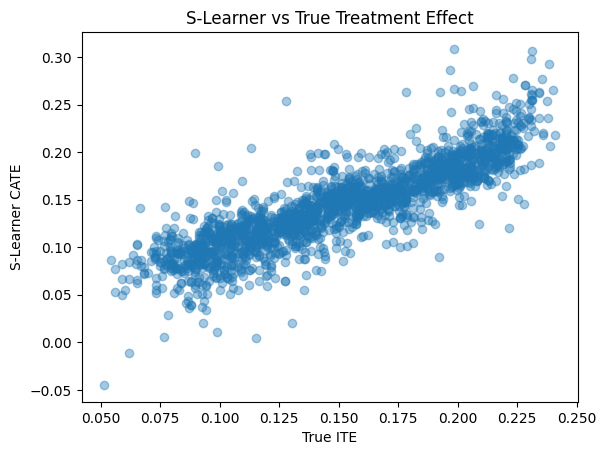

In [ ]:
import matplotlib.pyplot as plt

sample = df.sample(2000, random_state=42)

plt.scatter(sample["true_ite"], sample["s_learner_cate"], alpha=0.4)
plt.xlabel("True ITE")
plt.ylabel("S-Learner CATE")
plt.title("S-Learner vs True Treatment Effect")
plt.show()

# Implementation: T-Learner

In [ ]:
features = [
    "age",
    "income",
    "engagement",
    "past_purchases",
    "website_visits"
]

treated = df[df["treatment"] == 1]
control = df[df["treatment"] == 0]

model_treated = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model_control = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model_treated.fit(treated[features], treated["purchase"])
model_control.fit(control[features], control["purchase"])

RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
X_all = df[features]

p_treated = model_treated.predict_proba(X_all)[:, 1]
p_control = model_control.predict_proba(X_all)[:, 1]

df["t_learner_cate"] = p_treated - p_control

df[["true_ite", "s_learner_cate", "t_learner_cate"]].head(10)

,true_ite,s_learner_cate,t_learner_cate
0,0.200689,0.195270,0.218228
1,0.086689,0.104802,0.108667
2,0.106835,0.095702,0.087607
3,0.163226,0.137540,0.142159
4,0.101689,0.076092,0.098877
5,0.218726,0.206953,0.203556
6,0.206972,0.188821,0.210648
7,0.101444,0.109381,0.132559
8,0.128689,0.131551,0.134725
9,0.113726,0.119071,0.121697


In [ ]:
s_corr = df["true_ite"].corr(df["s_learner_cate"])
t_corr = df["true_ite"].corr(df["t_learner_cate"])

print("S-Learner correlation:", round(s_corr, 3))
print("T-Learner correlation:", round(t_corr, 3))

S-Learner correlation: 0.862
T-Learner correlation: 0.777


In [ ]:
print("True average effect:", round(df["true_ite"].mean(), 3))
print("S-Learner average:", round(df["s_learner_cate"].mean(), 3))
print("T-Learner average:", round(df["t_learner_cate"].mean(), 3))

True average effect: 0.151
S-Learner average: 0.144
T-Learner average: 0.151


# Creating Train/ Test

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42
)

print("Training rows:", len(train))
print("Test rows:", len(test))

Training rows: 35000
Test rows: 15000


In [ ]:
features = [
    "age",
    "income",
    "engagement",
    "past_purchases",
    "website_visits",
    "treatment"
]

s_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

s_model.fit(train[features], train["purchase"])

RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
X_test_treated = test[features].copy()
X_test_treated["treatment"] = 1

X_test_control = test[features].copy()
X_test_control["treatment"] = 0

test["s_cate"] = (
    s_model.predict_proba(X_test_treated)[:, 1]
    - s_model.predict_proba(X_test_control)[:, 1]
)

test[["true_ite", "s_cate"]].head(10)

,true_ite,s_cate
33553,0.208835,0.202974
9427,0.134972,0.146511
199,0.176363,0.169558
12447,0.100226,0.105741
39489,0.231052,0.257563
42724,0.134972,0.105254
10822,0.140972,0.155248
49498,0.100472,0.126377
4144,0.188000,0.219008
36958,0.089000,0.138845


In [ ]:
from sklearn.metrics import mean_absolute_error

correlation = test["true_ite"].corr(test["s_cate"])
mae = mean_absolute_error(test["true_ite"], test["s_cate"])

print("Correlation:", round(correlation, 3))
print("MAE:", round(mae, 3))


Correlation: 0.812
MAE: 0.021


In [ ]:
model_treated = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model_control = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

model_treated.fit(
    train[train["treatment"] == 1][features[:-1]],
    train[train["treatment"] == 1]["purchase"]
)

model_control.fit(
    train[train["treatment"] == 0][features[:-1]],
    train[train["treatment"] == 0]["purchase"]
)

RandomForestClassifier(max_depth=8, random_state=42)

In [ ]:
X_test = test[features[:-1]]

p_treated = model_treated.predict_proba(X_test)[:, 1]
p_control = model_control.predict_proba(X_test)[:, 1]

test["t_cate"] = p_treated - p_control

test[["true_ite", "s_cate", "t_cate"]].head(10)

,true_ite,s_cate,t_cate
33553,0.208835,0.202974,0.208278
9427,0.134972,0.146511,0.133963
199,0.176363,0.169558,0.161188
12447,0.100226,0.105741,0.093060
39489,0.231052,0.257563,0.302897
42724,0.134972,0.105254,0.124308
10822,0.140972,0.155248,0.144899
49498,0.100472,0.126377,0.136230
4144,0.188000,0.219008,0.214967
36958,0.089000,0.138845,0.158570


In [ ]:
t_correlation = test["true_ite"].corr(test["t_cate"])
t_mae = mean_absolute_error(test["true_ite"], test["t_cate"])

print("S-Learner correlation:", round(test["true_ite"].corr(test["s_cate"]), 3))
print("T-Learner correlation:", round(t_correlation, 3))

print("S-Learner MAE:", round(mean_absolute_error(test["true_ite"], test["s_cate"]), 3))
print("T-Learner MAE:", round(t_mae, 3))

S-Learner correlation: 0.812
T-Learner correlation: 0.757
S-Learner MAE: 0.021
T-Learner MAE: 0.027


In [ ]:
train_treated = train[train["treatment"] == 1].copy()
train_control = train[train["treatment"] == 0].copy()

train_treated["d1"] = (
    train_treated["purchase"]
    - model_control.predict_proba(train_treated[features[:-1]])[:, 1]
)

train_control["d0"] = (
    model_treated.predict_proba(train_control[features[:-1]])[:, 1]
    - train_control["purchase"]
)


In [ ]:
from sklearn.ensemble import  RandomForestRegressor

x_model_treated = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

x_model_control = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

x_model_treated.fit(
    train_treated[features[:-1]],
    train_treated["d1"]
)

x_model_control.fit(
    train_control[features[:-1]],
    train_control["d0"]
)

RandomForestRegressor(max_depth=8, random_state=42)

In [ ]:
X_test = test[features[:-1]]

effect_treated = x_model_treated.predict(X_test)
effect_control = x_model_control.predict(X_test)

test["x_cate"] = (effect_treated + effect_control) / 2

test[["true_ite", "s_cate", "t_cate", "x_cate"]].head(10)

,true_ite,s_cate,t_cate,x_cate
33553,0.208835,0.202974,0.208278,0.191121
9427,0.134972,0.146511,0.133963,0.145432
199,0.176363,0.169558,0.161188,0.189140
12447,0.100226,0.105741,0.093060,0.094539
39489,0.231052,0.257563,0.302897,0.250867
42724,0.134972,0.105254,0.124308,0.143032
10822,0.140972,0.155248,0.144899,0.165405
49498,0.100472,0.126377,0.136230,0.130182
4144,0.188000,0.219008,0.214967,0.219159
36958,0.089000,0.138845,0.158570,0.142038


In [ ]:
x_correlation = test["true_ite"].corr(test["x_cate"])
x_mae = mean_absolute_error(test["true_ite"], test["x_cate"])

print("S-Learner correlation:", round(test["true_ite"].corr(test["s_cate"]), 3))
print("T-Learner correlation:", round(test["true_ite"].corr(test["t_cate"]), 3))
print("X-Learner correlation:", round(x_correlation, 3))

print("S-Learner MAE:", round(mean_absolute_error(test["true_ite"], test["s_cate"]), 3))
print("T-Learner MAE:", round(t_mae, 3))
print("X-Learner MAE:", round(x_mae, 3))

S-Learner correlation: 0.812
T-Learner correlation: 0.757
X-Learner correlation: 0.811
S-Learner MAE: 0.021
T-Learner MAE: 0.027
X-Learner MAE: 0.023


#Preliminary Experimental Study

To understand heterogeneous treatment effects, I created a synthetic dataset of 50,000 customers representing a digital advertising scenario. Each customer has characteristics such as age, income, engagement, past purchases, and website visits. Customers were randomly assigned to either receive an advertisement (treatment = 1) or not receive it (treatment = 0), and a binary purchase outcome was generated.

I first conducted a traditional A/B test to estimate the Average Treatment Effect (ATE). The conversion rate was approximately 26.95% for the control group and 42.13% for the treatment group, giving an estimated ATE of approximately 15.2 percentage points.

However, the data was designed so that the effect of the advertisement was not the same for every customer. Customers with lower engagement had a larger treatment effect than customers with higher engagement. For example, the true average treatment effect within the low-engagement group was approximately 18.75%, compared with 11.29% for the high-engagement group. This demonstrated how an overall ATE can hide important differences between groups.

I then applied three Causal ML approaches: S-Learner, T-Learner, and X-Learner. The models were trained on 70% of the data and evaluated on the remaining 30% to avoid evaluating them on the same observations used for training. Their estimated CATEs were compared against the known treatment effects in the synthetic data.

| Method    | Correlation with True ITE |       MAE |
| --------- | ------------------------: | --------: |
| S-Learner |                 **0.812** | **0.021** |
| X-Learner |                     0.811 |     0.023 |
| T-Learner |                     0.757 |     0.027 |


In this particular experiment, the S-Learner performed best, while the X-Learner produced very similar results. The T-Learner had the highest error among the three. These results should not be interpreted as one method being universally better; rather, they provide a starting point for investigating how the performance of different Causal ML methods changes under different data conditions.

This gives us a good foundation for the next stage: systematically changing characteristics such as sample size, treatment imbalance, and the amount of treatment-effect heterogeneity, and observing how the different methods respond.